#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss
from src.gnn.models import GAT

#### Load data

In [ ]:
data, device = load_and_preprocess_data('../data/processed/elliptic_pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Multi-seed

In [4]:
import numpy as np
import torch
from src.gnn.seed import set_seed
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate

seeds = [42, 0, 123]
results = []

for seed in seeds:
    print(f"\n{'='*40}\nRUNNING GAT WITH SEED {seed}\n{'='*40}")
    
    set_seed(seed)
    
    model = GAT(
        in_channels=data.x.shape[1], 
        hidden_channels=64,
        out_channels=2, 
        heads=2,      
        dropout=0.5
    ).to(device)
    
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    save_path = f'../saved_models/gat_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model=model, 
        data=data, 
        optimizer=optimizer, 
        criterion=criterion, 
        save_path=save_path, 
        num_epochs=200, 
        patience=20,
        monitor_metric='f1_ill',
        clip_grad_norm=1.0 
    )
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    
    results.append({
        'seed': seed,
        'f1_ill': test_metrics['f1_ill'],
        'precision': test_metrics['precision_ill'],
        'recall': test_metrics['recall_ill'],
        'auc_pr': test_metrics['auc_pr']
    })

f1_ill_list = [res['f1_ill'] for res in results]
precision_list = [res['precision'] for res in results]
recall_list = [res['recall'] for res in results]
auc_pr_list = [res['auc_pr'] for res in results]

print(f"\n{'='*40}\nFINAL GAT MULTI-SEED RESULTS\n{'='*40}")
print(f"F1(illicit): {np.mean(f1_ill_list):.4f} ± {np.std(f1_ill_list):.4f}")
print(f"Precision  : {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")
print(f"Recall     : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"AUC-PR     : {np.mean(auc_pr_list):.4f} ± {np.std(auc_pr_list):.4f}")



RUNNING GAT WITH SEED 42
Class weights: licit=1.00, illicit=2.86
Epoch 001: Train Loss=1.0876, Train F1=0.3706, Val F1=0.3504, Gap=0.0202
Epoch 002: Train Loss=0.7708, Train F1=0.5625, Val F1=0.4287, Gap=0.1338
Epoch 003: Train Loss=0.8008, Train F1=0.4611, Val F1=0.5123, Gap=-0.0512
Epoch 004: Train Loss=0.8362, Train F1=0.5850, Val F1=0.4053, Gap=0.1798
Epoch 005: Train Loss=0.6032, Train F1=0.4905, Val F1=0.3760, Gap=0.1146
Epoch 006: Train Loss=0.5921, Train F1=0.4135, Val F1=0.3696, Gap=0.0439
Epoch 007: Train Loss=0.6042, Train F1=0.4380, Val F1=0.3707, Gap=0.0673
Epoch 008: Train Loss=0.5493, Train F1=0.5330, Val F1=0.4006, Gap=0.1325
Epoch 009: Train Loss=3.1104, Train F1=0.6596, Val F1=0.4663, Gap=0.1934
Epoch 010: Train Loss=1.2850, Train F1=0.7172, Val F1=0.6120, Gap=0.1053
Epoch 011: Train Loss=0.5121, Train F1=0.6889, Val F1=0.6349, Gap=0.0541
Epoch 012: Train Loss=0.5153, Train F1=0.6735, Val F1=0.5034, Gap=0.1701
Epoch 013: Train Loss=0.4767, Train F1=0.5653, Val F1=0.4

#### Define model

In [4]:
model = GAT(
    in_channels=data.x.shape[1], 
    hidden_channels=64,
    out_channels=2, 
    heads=2,      
    dropout=0.5
).to(device)

print(model)

GAT(
  (conv1): GATv2Conv(165, 64, heads=2)
  (conv2): GATv2Conv(128, 2, heads=1)
)


#### Focal Loss and Optimizer

In [5]:
weight = compute_class_weights(data, device)

criterion = torch.nn.CrossEntropyLoss(weight=weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model=model, 
    data=data, 
    optimizer=optimizer, 
    criterion=criterion, 
    save_path='../saved_models/gat_best.pt', 
    num_epochs=200, 
    patience=20,
    clip_grad_norm=1.0 
)

Epoch 001: Train Loss=1.0876, Train F1=0.3706, Val F1=0.3504, Gap=0.0202
Epoch 002: Train Loss=0.7708, Train F1=0.5625, Val F1=0.4287, Gap=0.1338
Epoch 003: Train Loss=0.8008, Train F1=0.4611, Val F1=0.5123, Gap=-0.0512
Epoch 004: Train Loss=0.8362, Train F1=0.5850, Val F1=0.4053, Gap=0.1798
Epoch 005: Train Loss=0.6032, Train F1=0.4905, Val F1=0.3760, Gap=0.1146
Epoch 006: Train Loss=0.5921, Train F1=0.4135, Val F1=0.3696, Gap=0.0439
Epoch 007: Train Loss=0.6042, Train F1=0.4380, Val F1=0.3707, Gap=0.0673
Epoch 008: Train Loss=0.5493, Train F1=0.5330, Val F1=0.4006, Gap=0.1325
Epoch 009: Train Loss=3.1104, Train F1=0.6596, Val F1=0.4663, Gap=0.1934
Epoch 010: Train Loss=1.2850, Train F1=0.7172, Val F1=0.6120, Gap=0.1053
Epoch 011: Train Loss=0.5121, Train F1=0.6889, Val F1=0.6349, Gap=0.0541
Epoch 012: Train Loss=0.5153, Train F1=0.6735, Val F1=0.5034, Gap=0.1701
Epoch 013: Train Loss=0.4767, Train F1=0.5653, Val F1=0.4090, Gap=0.1563
Epoch 014: Train Loss=0.4543, Train F1=0.5013, Val

#### Learning curve

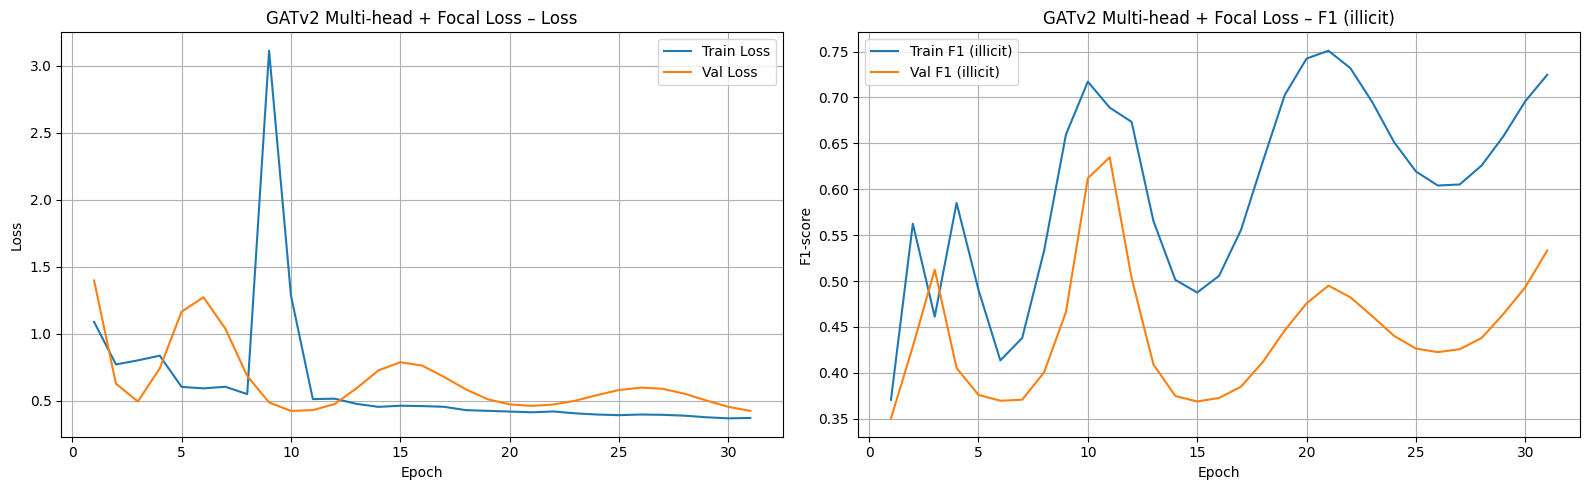

In [7]:
plot_learning_curves(history, model_name="GATv2 Multi-head + Focal Loss")

#### Threshold ablation

In [8]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch.nn.functional as F

model.load_state_dict(torch.load('../saved_models/gat_best.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1]

print("Dò tìm Fine-grained Threshold trên tập Validation:")
best_thresh = 0.70
best_f1 = 0.0

for thresh in np.arange(0.70, 0.81, 0.01):
    preds = (probs[data.val_mask] > thresh).long()
    f1 = f1_score(data.y[data.val_mask].cpu(), preds.cpu(), pos_label=1, zero_division=0)
    print(f"thresh={thresh:.2f}, Val F1(ill)={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest threshold tối ưu tìm được: {best_thresh:.2f} (Val F1 = {best_f1:.4f})")

print(f" GAT Test Set Evaluation (sử dụng Threshold = {best_thresh:.2f})")
print("="*60)

preds_test = (probs[data.test_mask] > best_thresh).long()
y_true_test = data.y[data.test_mask].cpu()
y_pred_test = preds_test.cpu()

print("\nClassification Report:")
print(classification_report(
    y_true_test,
    y_pred_test,
    target_names=["Licit (0)", "Illicit (1)"],
    digits=4,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_test, y_pred_test))


Dò tìm Fine-grained Threshold trên tập Validation:
thresh=0.70, Val F1(ill)=0.4617
thresh=0.71, Val F1(ill)=0.4593
thresh=0.72, Val F1(ill)=0.4541
thresh=0.73, Val F1(ill)=0.4481
thresh=0.74, Val F1(ill)=0.4481
thresh=0.75, Val F1(ill)=0.4393
thresh=0.76, Val F1(ill)=0.4350
thresh=0.77, Val F1(ill)=0.4269
thresh=0.78, Val F1(ill)=0.4100
thresh=0.79, Val F1(ill)=0.3920
thresh=0.80, Val F1(ill)=0.3844
thresh=0.81, Val F1(ill)=0.3843

Best threshold tối ưu tìm được: 0.70 (Val F1 = 0.4617)
 GAT Test Set Evaluation (sử dụng Threshold = 0.70)

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9507    0.9856    0.9678     15587
 Illicit (1)     0.5608    0.2641    0.3591      1083

    accuracy                         0.9388     16670
   macro avg     0.7557    0.6249    0.6635     16670
weighted avg     0.9254    0.9388    0.9283     16670


Confusion Matrix:
[[15363   224]
 [  797   286]]
